In [1]:
# import numpy as np
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# from scipy.stats import norm
# #l = np.arange(0,100,1)
# #print(wrapped_norm_pdf(l, 49, 2.8, 100))

In [2]:
""" import numpy as np
from scipy.stats import norm

def wrapped_norm_pdf(x, mean, std, wrap_size):
    
    # 安定化
    std = max(float(std), 1e-10)
    wrap_size = int(wrap_size)

    # インデックス系を用意
    idx = np.arange(wrap_size, dtype=int)

    # “中心”に置いたガウス（中心は floor(wrap_size/2) でOK）
    center = wrap_size // 2
    base = norm.pdf(idx, loc=center, scale=std)  # shape = (wrap_size,)

    # 目的の mean になるよう円環上でシフト
    shift = (int(mean) - center) % wrap_size
    rolled = np.roll(base, shift)  # shape = (wrap_size,)

    # 任意の x に対応（整数インデックスとして扱う）
    x = np.asarray(x)
    x_idx = np.mod(x.astype(int), wrap_size)
    wrapped_pdf = rolled[x_idx]

    return wrapped_pdf.astype(np.float64) """

' import numpy as np\nfrom scipy.stats import norm\n\ndef wrapped_norm_pdf(x, mean, std, wrap_size):\n\n    # 安定化\n    std = max(float(std), 1e-10)\n    wrap_size = int(wrap_size)\n\n    # インデックス系を用意\n    idx = np.arange(wrap_size, dtype=int)\n\n    # “中心”に置いたガウス（中心は floor(wrap_size/2) でOK）\n    center = wrap_size // 2\n    base = norm.pdf(idx, loc=center, scale=std)  # shape = (wrap_size,)\n\n    # 目的の mean になるよう円環上でシフト\n    shift = (int(mean) - center) % wrap_size\n    rolled = np.roll(base, shift)  # shape = (wrap_size,)\n\n    # 任意の x に対応（整数インデックスとして扱う）\n    x = np.asarray(x)\n    x_idx = np.mod(x.astype(int), wrap_size)\n    wrapped_pdf = rolled[x_idx]\n\n    return wrapped_pdf.astype(np.float64) '

[[[0 0 0]]

 [[1 1 1]]

 [[2 2 2]]]


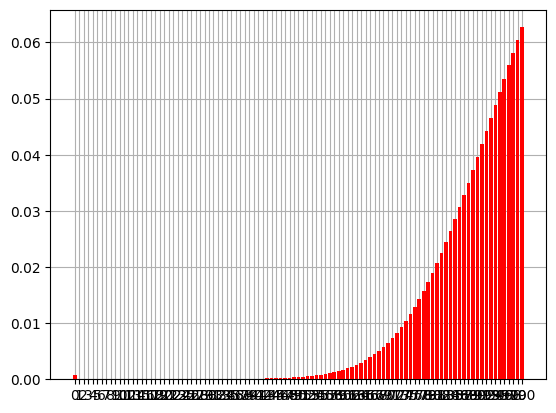

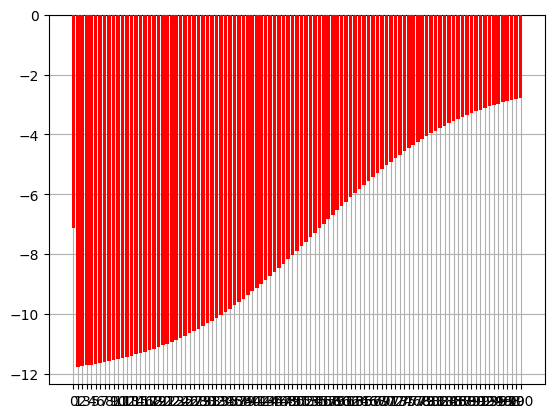

In [ ]:
from pymdp import utils
import numpy as np
from scipy.stats import norm
import math
from pymdp.maths import softmax

import jax.numpy as jnp
import jax.tree_util as jtu
from jax import random as jr, config, jit
from pymdp.jax.agent import Agent as AIFAgent
from functools import partial
from equinox import tree_at

from pymdp.jax.maths import log_stable
import jax


# シードを毎回変える場合
#import time
#seed = int(time.time())
wd=1
ws=1

seedjax=38#45#乱数シード固定38,,39
seed_value=3
num_slot=2
num_iter=32
tau=0.1
use_param_info_gain=False
learn_A=False
learn_B=False
e=0.001#観測モデルの下駄（定常発火）0.0001
Timerange=20
#観測モデルの標準偏差（支払い値をサンプリングするガウス分布の標準偏差）
w_novelty=10
""" initial_mean1=60##スロット1の初期平均支払値
initial_mean2=40##スロット2の初期平均支払値
initial_mean3=50
initial_mean4=50 
initial_mean=[initial_mean1,initial_mean2,initial_mean3,initial_mean4]"""
sa1=8#12
sa2=4#0.001#12#0.001#0.001#12#12#0.001#12#0.001#0.001#12#8#16#0.001#16
sa3=sa1
sa4=sa2

sa=[sa1, sa2,sa3,sa4]
pAscale=1E-2#0#2
sc=0.0001
pBscale=1*sc#1E-1#2#1E-2#0#2

sb1=2#0.001#4#0.001#4#0.001#4##0.001#4#4#2.8#2.8#4#2.8#0.8#1#0.8#1#0.5#1#0.7#1#0.9#1#0.91#状態遷移の標準偏差
sb2=sb1
sb3=sb1#4.28
sb4=sb3#sb1
sb=[sb1, sb2,sb3,sb4]
sA1=sa1#0.16
sA2=sA1
sA3=sA1
sA4=sA1
sA=[sA1, sA2,sA3,sA4]
lr_pA=1
fr_pA=1
lr_pB=5*sc
fr_pB=0.5#0.95
#objective_function=pbs+pbs_pA
deltaS1=0
deltaS2=0
deltaS3=0
deltaS4=0
deltaS=[deltaS1,deltaS2,deltaS3,deltaS4]
num_dim=100
ramda=0.98363#減衰ランダムウォークの減衰パラメータ
#o_control=5#観測（支払い値）のデータ
#u_control=1#選択された行動（スロット）
c_pre=10#preferenceの精度
# b=0.1
# x0=80#80
b=0.06
x_mid=55
#cshape=2#選好関数の形状（対数の底）
alpha=1#32#512#102400#1.0#0.837#行動選択の精度

num_obs=[]
num_states=[]
num_controls=[]
for i in range(num_slot):
    num_obs.append(num_dim+1)
    num_states.append(num_dim)
    num_controls.append(num_slot+1)
num_obs.append(num_slot+1)#行動の観測の次元数．スロットの数＋平均支払値シャッフル
num_states.append(num_slot+1)#行動の状態．各スロットを選ぶ＋平均支払値シャッフル
num_controls.append(num_slot+1)#各スロットを選ぶ＋平均支払値シャッフル
num_states_A = [num_dim,  num_slot+1]
Ns1=num_states[0]
#policies=np.array([[[0,0,0,0,0]],[[1,1,1,1,1]],[[2,2,2,2,2]],[[3,3,3,3,3]]])

#policies = np.array([[[i] * (num_slot + 1)] for i in range(num_slot)])
policies = np.array([[[i] * (num_slot + 1)] for i in range(num_slot+1)])#各スロットを選ぶポリシー＋平均支払値をシャッフルするポリシー
print(policies)
num_factors = len(num_states)
D = utils.obj_array(num_factors)#初期事前分布の設定
for i in range(num_slot):
    D[i] = np.ones(num_dim)/num_dim


# D[0]~D[4]まで格納
#D = {}
""" for i in range(4):
    D[i] = normalized_E.copy() """
D[num_slot] = np.array([1/(num_slot+1) for _ in range(num_slot+1)])
D_env=utils.obj_array(num_factors)
for k in range(0,num_slot,1):
    """ D_env[k]=np.zeros(num_dim, dtype=float)
    D_env[k][initial_mean[k]-1] = 1.0 """

    D_env[k]=np.ones(num_dim)/num_dim ##初期平均支払値を決める確率分布
    



l = np.arange(0,num_dim,1)                 
#A_array = utils.random_A_matrix(num_obs, num_states) # create sensory likelihood (A matrix)
A_shapes = [[o_dim] + num_states_A for o_dim in num_obs[0:num_slot]]# [4] + num_states_A2 
A_shapes.append([num_slot+1,num_slot+1])
# initialize the A array to all 0's
A_array = utils.obj_array_zeros(A_shapes)

for j in range(num_slot):
    for m in range(0,num_states[j],1):
        for n in range(num_slot+1):
            if n==j:
                A_array[j][0,m,n]=0 #スロット1を選択したとき（制御状態0），スロット1の「支払値なし」の観測が生成される確率は0
                #A_array[j][1:(num_dim+1),m,n]=wrapped_norm_pdf(l, m, sa[j], num_dim)+e
                A_array[j][1:(num_dim+1),m,n]=norm.pdf(l, m, sa[j])#+e

            else:
                #A_array[0][1:101,m,0]=  norm.pdf(l,m,sa1)+e #平均m（因子1の隠れ状態）標準偏差sa1の正規分布にもとづく確率密度，10次元のベクトル．
                A_array[j][0,m,n]=1#スロット1を選択したとき（制御状態0），スロット2の「支払値なし」の観測が生成される確率は1.
        
    #A_array[3][1:101,p,3]=norm.pdf(l,p,sa4)+e
for q in range(0,num_states[num_slot],1):
    
    A_array[num_slot][q,q]=1

A_array = utils.norm_dist_obj_arr(A_array)#列ごとに正規化            

B_shapes = [[s_dim, s_dim, num_controls[f]] for f, s_dim in enumerate(num_states)]

# initialize the B array to all 0's
B_array = utils.obj_array_zeros(B_shapes)
theta=4 #減衰中心

#初期仮説
for k in range(0,num_slot,1):
    #for u in range(0,num_controls[k],1):
    for u in range(0,num_controls[k]-1,1):
        for st in range(0,num_states[k],1): 
            #B_array[k][:,st,u]=wrapped_norm_pdf(l, st, sb[k], num_dim)
            B_array[k][:,st,u]=norm.pdf(l, st, sb[k])
    """3つ目の行動に対する状態遷移の予測"""
    B_array[k][:,:,num_controls[k]-1]=jnp.ones(num_dim) ##完全ランダム遷移


for controls in range(0,num_states[num_slot],1):
    B_array[num_slot][controls,:,controls]=[1] *( num_slot+1)#選択された制御状態に確率1で遷移する．
B_array = utils.norm_dist_obj_arr(B_array)#列ごとに正規化  


C_shapes = [[o_dim] for o_dim in num_obs]
#print(C_shapes)
C_vector = utils.obj_array_zeros(C_shapes)

# ##Cフラット，学習」
# for k in range(0,num_slot,1):
#     C_vector[k][0]=0
#     for m in range(1,num_obs[k],1):
#         C_vector[k][m] = cgrad* math.log(m+c_shift)#スロット1の支払値に対する選好．対数関数で定義．
# # 1) 対数型: f(x) = a * log(1 + b x)
# # 条件: b > 0
# for k in range(0, num_slot, 1):
#     C_vector[k][0] = 0
#     for m in range(1, num_obs[k], 1):
#         C_vector[k][m] = cgrad * math.log1p(b * (m ))
# # 2) 指数飽和型: f(x) = a * (1 - exp(-b x))
# # 条件: b > 0
# for k in range(0, num_slot, 1):
#     C_vector[k][0] = 0
#     for m in range(1, num_obs[k], 1):
#         # -expm1(-z) は 1 - exp(-z) と同値で数値的に安定
#         C_vector[k][m] = cgrad * (-math.expm1(-b * m ))
# 3) べき乗型: f(x) = a * ((1 + b x)^r - 1)  （0 < r < 1）
# 条件: b > 0, 0 < r < 1
# for k in range(0, num_slot, 1):
#     C_vector[k][0] = 0
#     for m in range(1, num_obs[k], 1):
#         C_vector[k][m] = cgrad * ((1.0 + b * (m ))**r - 1.0)
#指数飽和型関数
# eps = 1e-12
# for k in range(0, num_slot, 1):
#     # Cの生値をまず作る（倍率は付けない）
#     for m in range(0, num_obs[k], 1):
#         x = m  # 既存の c_shift は使わず、x0 に統合する
#         #val = 0.0
        
#         val = cgrad*(- math.exp(-b * (x - x0)) ) # 常に下に凸
#         C_vector[k][m] = val  # ゼロ回避

eps = 1e-12
for k in range(0, num_slot, 1):
    for m in range(0, num_obs[k], 1):
        x = m
        t = b * (x - x_mid)
        # 数値安定（オーバーフロー防止）
        #t = max(min(t, 60.0), -60.0)
        sig = 1.0 / (1.0 + math.exp(-t))  # 0..1
        C_vector[k][m] = c_pre * sig #+ eps
    C_vector[k][0] = C_vector[k][x_mid] ##「支払値なし」に対する選好はx_mid（主観的な報酬と損失の境界）と同じに設定

# eps = 1e-12
# for k in range(0, num_slot, 1):
#     for m in range(0, num_obs[k], 1):
#         x = m
#         t = b * (x - x_mid)
#         # 数値安定
#         t = max(min(t, 60.0), -60.0)
#         gompertz = math.exp(-math.exp(-t))  # 0..1
#         C_vector[k][m] = cgrad * gompertz + eps
# for k in range(0, num_slot, 1):
#     for m in range(0, num_obs[k], 1):
#         x = m  # c_shiftは使わず、中心はx_midで指定
#         val = 1.0 / (1.0 + math.exp(-b * (x - x_mid)))  # S字（変曲点 x_mid）
#         C_vector[k][m] = max(val, 0.0) + eps


from pymdp.utils import plot_beliefs, plot_likelihood,plot_likelihood_figsize
#print(A_array[0][:,:,0,0,0,0])
plot_beliefs(softmax(C_vector[0]))

for i in range(num_slot):
    C_vector[i]=np.log(softmax(C_vector[i]))

plot_beliefs(C_vector[0])#
#print(C_vector)
#C_vector = utils.obj_array_uniform(num_obs) # uniform preferences

In [4]:
# print(D[0])
# print(D[1])
#print(D[4])

In [ ]:
#print(A_array)
#print(B_array)
#print(C_vector)

[array([ -7.1395678 , -11.7626889 , -11.74031446, -11.71667008,
        -11.69169077, -11.66530907, -11.63745507, -11.60805644,
        -11.57703847, -11.54432414, -11.50983424, -11.47348745,
        -11.43520049, -11.39488835, -11.35246443, -11.30784084,
        -11.26092865, -11.21163827, -11.15987976, -11.10556329,
        -11.04859959, -10.98890048, -10.92637942, -10.86095214,
        -10.79253728, -10.72105715, -10.64643846, -10.56861311,
        -10.4875191 , -10.40310133, -10.31531256, -10.22411432,
        -10.1294778 , -10.03138487,  -9.92982888,  -9.82481564,
         -9.71636419,  -9.60450764,  -9.4892938 ,  -9.37078585,
         -9.24906283,  -9.12421996,  -8.99636894,  -8.86563797,
         -8.73217169,  -8.59613086,  -8.45769198,  -8.31704655,
         -8.1744003 ,  -8.02997214,  -7.88399297,  -7.73670429,
         -7.58835673,  -7.43920832,  -7.28952282,  -7.1395678 ,
         -6.98961279,  -6.83992728,  -6.69077888,  -6.54243131,
         -6.39514263,  -6.24916346,  -6.

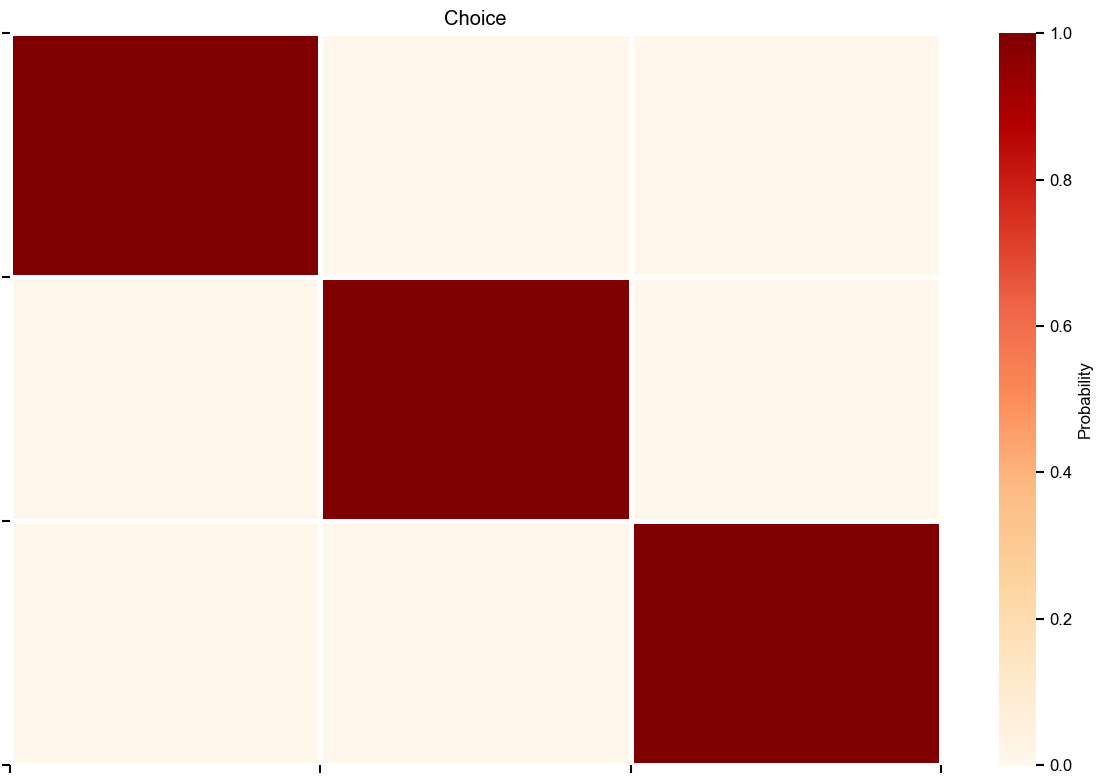

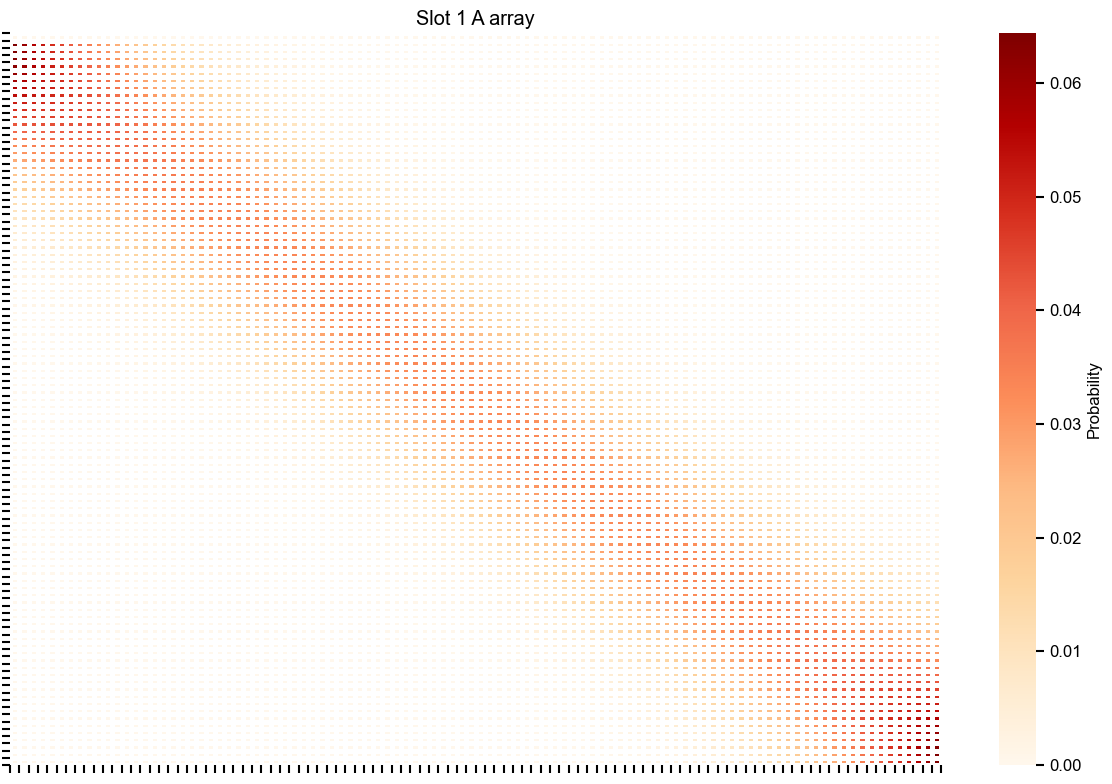

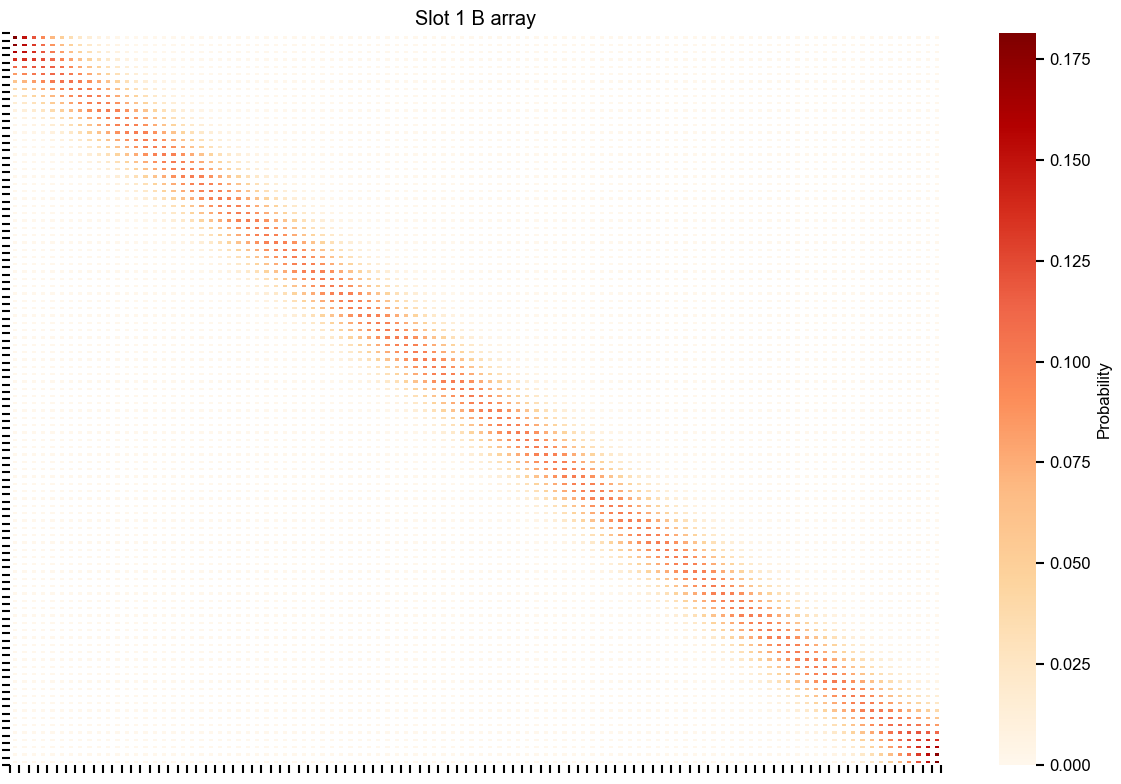

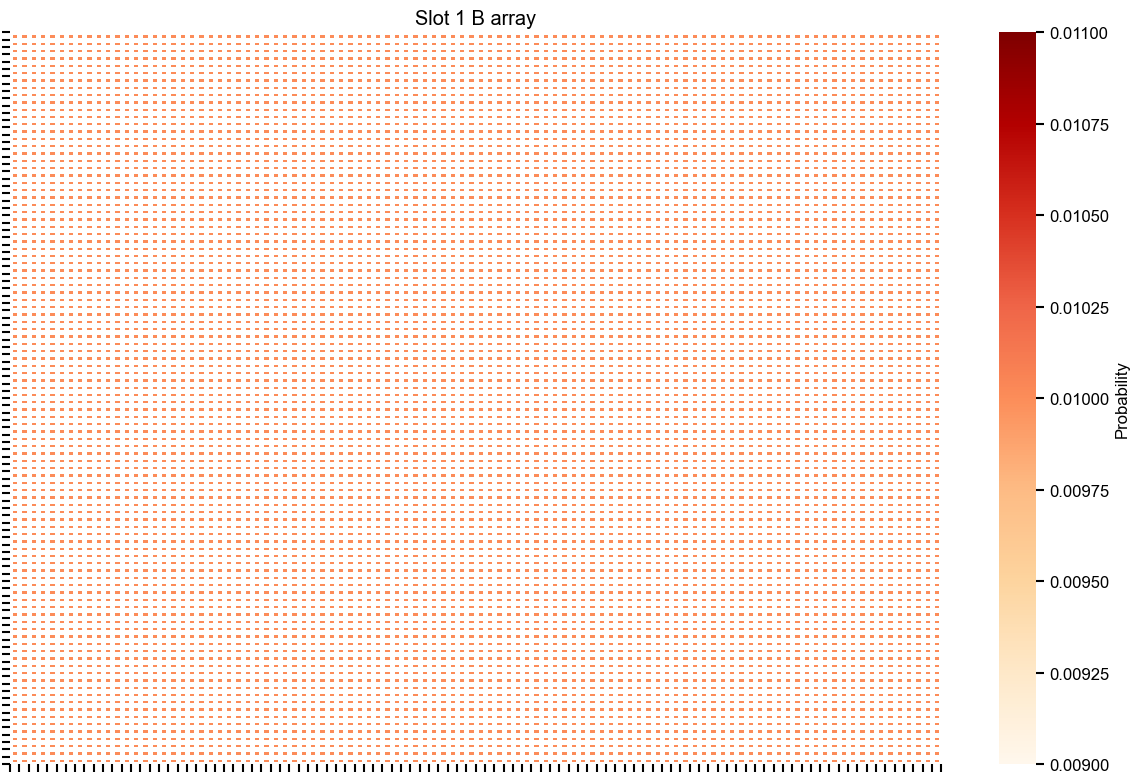

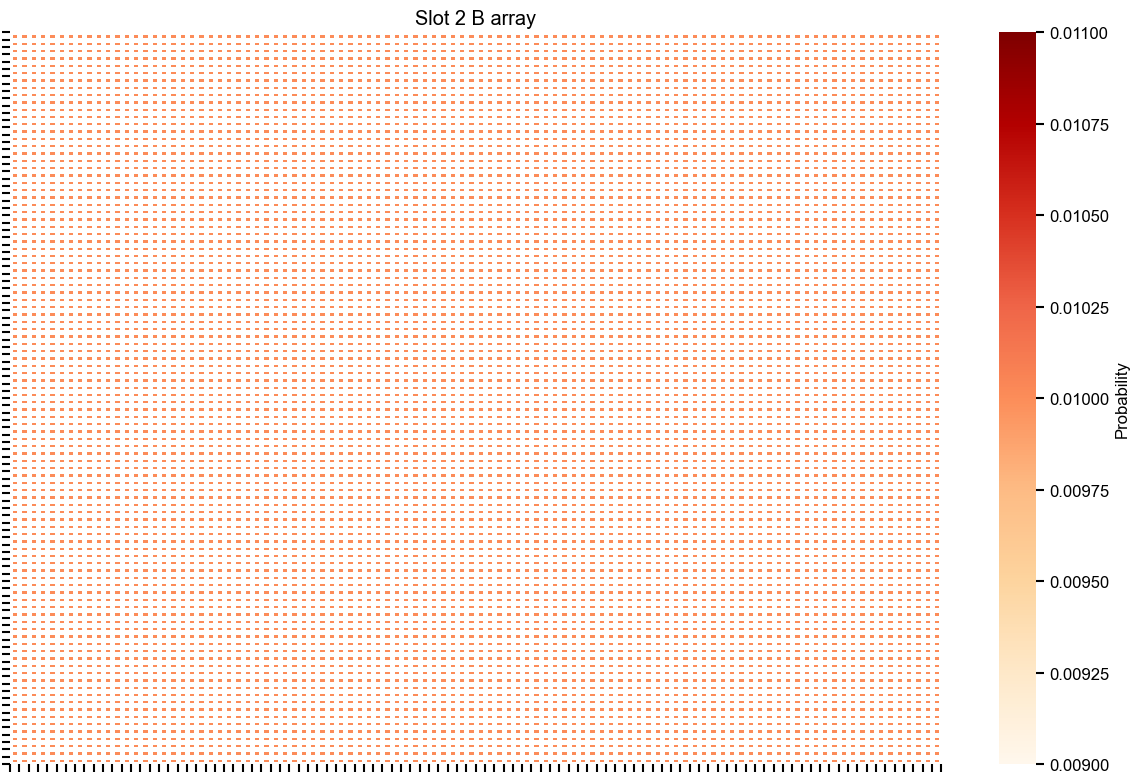

In [28]:
from pymdp.utils import plot_beliefs, plot_likelihood,plot_likelihood_figsize
#print(A_array[0][:,:,0,0,0,0])
#plot_beliefs(C_vector[0])
#plot_beliefs(softmax(C_vector[0]))
#plot_likelihood_figsize(B_array[2][:,:,1],'Slot 1 B array')
plot_likelihood_figsize(A_array[2][:,:],'Choice')
plot_likelihood_figsize(A_array[0][:,:,0],'Slot 1 A array')
#print(A_array[0][:,:,0])
plot_likelihood_figsize(B_array[0][:,:,0],'Slot 1 B array')
plot_likelihood_figsize(B_array[0][:,:,2],'Slot 1 B array')
plot_likelihood_figsize(B_array[1][:,:,2],'Slot 2 B array')

In [7]:
class FourArmedBandit(object):#生成プロセスの定義

  def __init__(self, D_env):#初期化関数．各スロットの初期値をランダムに決定．
    rand_seq=[]
    rng = np.random.default_rng(seed=seed_value)
    self.s_slot=np.zeros((num_slot), dtype=int)
    for i in range (num_slot):
      np.random.seed(seed_value+i)  # ここで一度だけ設定
      self.s_slot[i]=utils.sample(D_env[i])
      print(f"slot{i}:",self.s_slot[i])
      rand_seq.append(rng.normal(loc=0.0, scale=sb[i], size=2*Timerange))#スロット1と2の遷移の乱数は別
    self.idx = np.zeros((num_slot), dtype=int)
    np.random.seed(seed_value)  # ここで一度だけ設定

    #self.rand_seq = rng.random(size=2*num_slot*30)#確率で制御
    #rand_seq = rng.normal(loc=0.0, scale=sb1, size=2*num_slot*30)#標準偏差で制御
    self.rand_seq = rand_seq

    """ self.s_slot1 = utils.sample(D_env[0]) # randomly sample which bandit arm is better (Left or Right)
    self.s_slot2 = utils.sample(D_env[1])
    self.s_slot3 = utils.sample(D_env[2])
    self.s_slot4 = utils.sample(D_env[3])
    self.s_action = utils.sample(D_env[4]) """

  def step(self, action_idx):#観測の生成関数．#(self, action_idx, o_control):
    obs_slot=np.zeros((num_slot))
    """ obs_slot1=0 #0:no cue
    obs_slot2=0
    obs_slot3=0
    obs_slot4=0"""
    obs_action=0 
    
    #import random
    for i in range(num_slot):
      #u1 = self.rand_seq[self.idx]; self.idx += 1
      u1 = self.rand_seq[i][self.idx[i]]; self.idx[i] += 1 #使用する乱数を変更
      #self.s_slot[i]=round(self.s_slot[i]+deltaS[i]+rng.normal(0, sb[i]))#真の平均支払い値の遷移

     ##次時刻の平均支払値を決定．
      nexts=round(self.s_slot[i]+deltaS[i]+u1)
      self.s_slot[i]=nexts
      
      if self.s_slot[i]>num_dim-1:#平均支払い値を1~10に収める
          self.s_slot[i]-=num_dim
      if self.s_slot[i]<0:
          self.s_slot[i]+=num_dim
    
    action_idx= action_idx[0][num_slot] #制御状態が0のとき（スロット1を選択したとき）:
    """3つ目の行動に対する状態遷移（生成プロセス）"""
    if action_idx==num_slot: ##シャッフルボタンが押されたとき
        for i in range (num_slot):
            np.random.seed(seed_value+i*10)  # 適当な乱数シードに変更
            D_env_temp = np.ones(num_dim)/num_dim
            self.s_slot[i]=utils.sample(D_env_temp)
            print(f"slot{i}:",self.s_slot[i])
        np.random.seed(seed_value)  # 乱数シードをもとに戻す
        obs_action=action_idx
        obs_slot=list(obs_slot)
        obs_slot.append(obs_action)
        #obs = [obs_slot1, obs_slot2, obs_slot3, obs_slot4, obs_action]
        obs_jax = jtu.tree_map(lambda x: jnp.expand_dims(x, -1).astype(jnp.int32), obs_slot)#jax用にbatch次元？を追加
        true_s =list(self.s_slot)
            
    else: ##いずれかのスロットが選択されたとき
        ##選択されたスロットに対応する支払値の確率分布を準備
        A_env=np.zeros((num_dim+1))
        A_env[0]=0
        #A_env[1:101]=norm.pdf(l,self.s_slot1,sA1)
        #A_env[1:num_dim+1]=wrapped_norm_pdf(l,self.s_slot[action_idx],sA[action_idx],num_dim)
        A_env[1:num_dim+1]=norm.pdf(l,self.s_slot[action_idx],sA[action_idx])
        A_env = A_env/np.sum(A_env)
        ##支払値をサンプリング
        obs_slot[action_idx] = utils.sample(A_env)
        obs_action=action_idx

        obs_slot=list(obs_slot)
        obs_slot.append(obs_action)
        #obs=jnp.array(obs_slot)
        #obs = [obs_slot1, obs_slot2, obs_slot3, obs_slot4, obs_action]
        obs_jax = jtu.tree_map(lambda x: jnp.expand_dims(x, -1).astype(jnp.int32), obs_slot)#jax用にbatch次元？を追加
        true_s =list(self.s_slot)
    #true_s=[self.s_slot1, self.s_slot2, self.s_slot3, self.s_slot4]
    #return [[obs],[self] ]
    return obs_jax,true_s
  
  # def reset(self):#時刻1の観測のサンプリング#(self ,o_control):
  #   obs_slot=np.zeros((num_slot))
  #   """ obs_slot1=0 #0:no cue
  #   obs_slot2=0
  #   obs_slot3=0
  #   obs_slot4=0 """
  #   obs_action=0

  #   action_idx= self.s_action
      
  #   A_env=np.zeros((num_dim+1))
  #   A_env[0]=0
  #   #A_env[1:101]=norm.pdf(l,self.s_slot1,sA1)
  #   #A_env[1:num_dim+1]=wrapped_norm_pdf(l,self.s_slot[action_idx],sA[action_idx],num_dim)
  #   A_env[1:num_dim+1]=norm.pdf(l,self.s_slot[action_idx],sA[action_idx])
  #   A_env = A_env/np.sum(A_env)
  #   obs_slot[action_idx] = utils.sample(A_env)

    
  #     #obs_slot4 = o_control
  #   obs_slot=list(obs_slot)
  #   obs_slot.append(obs_action)
  #   #obs=jnp.array(obs_slot)
  #   #obs = [obs_slot1, obs_slot2, obs_slot3, obs_slot4,obs_action]
  #   #print(obs)
  #   obs_jax = jtu.tree_map(lambda x: jnp.expand_dims(x, -1).astype(jnp.int32), obs_slot)#jax用にbatch次元？を追加
  #   actions_t=[]
  #   for i in range(num_slot):
  #     actions_t.append(action_idx)
  #   actions_t=np.array([actions_t])
  #   #return [[obs],[self] ]
  #   #print(obs_jax)
  #   return obs_jax, actions_t

In [8]:
from jax import nn
def calc_action_selection_prob(agent,neg_efe):
    neg_efe_tmp=neg_efe.flatten()
    q_pi=nn.softmax(agent.gamma * neg_efe_tmp)
    #q_pi= jnp.broadcast_to(q_pi, (batch_size,))
    #q_pi= jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(q_pi))
    q_pi=jnp.expand_dims(q_pi, -2)
    return q_pi
#print(neg_efe)
#print(calc_action_selection_prob(agents4,neg_efe))

In [9]:
#def run_active_inference_loop(my_agent, my_env, T = 10):
batch_size = 1 # number of agents

#jax

A_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(A_array))#jax用にbatch次元を追加．
B_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(B_array))
C_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(C_vector))
D_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(D))

batch_keys = jr.split(jr.PRNGKey(0), batch_size)
#batch_keys = jr.split(batch_keys[0], batch_size)
#batch_keys = jr.split(batch_keys[0], batch_size)  

""" ###学習過程のためON
pA = utils.dirichlet_like(A_array, scale = pAscale)
pB = utils.dirichlet_like(B_array, scale = pBscale)
for i in range(num_slot):
    for j in range(num_slot):
        if i!=j:
            pA[i][:,:,j]=pA[i][:,:,j]*10000

pA[num_slot]=pA[num_slot]*10000
pA_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(pA))

for i in range(num_slot):
    for j in range(num_slot):
        if i!=j:
            pB[i][:,:,j]=pB[i][:,:,j]*10000

pB[num_slot]=pB[num_slot]*10000
pB_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(pB)) """
A_dependencies = [[i, num_slot] for i in range(num_slot)] + [[num_slot]]
print(A_dependencies)
#A_dependencies=[[0, num_slot], [1, num_slot], [2,  num_slot], [3, num_slot],[num_slot]]
B_dependencies=None
#AIFエージェントの宣言
agents = AIFAgent(A=A_jax, B=B_jax, C=C_jax, D=D_jax, E=None, pA=None, pB=None,  inference_algo="mmp", learn_A=learn_A, learn_B=learn_B, learn_C=False, learn_D=False, learn_E=False, A_dependencies=A_dependencies, B_dependencies=B_dependencies, policies=policies,gamma=1., alpha=alpha, action_selection="stochastic", policy_len=1, use_utility=True, use_states_info_gain=True, use_param_info_gain=use_param_info_gain, use_inductive=False, onehot_obs=False, sampling_mode="full",num_iter=num_iter)
#AIFの処理を行う関数．「@partial～」をコメントアウトするとupdate_agent内でもprint文で出力を確認可能．


[[0, 2], [1, 2], [2]]


In [10]:
#print(agents.D)

In [11]:
@partial(jit, static_argnames=['batch_size','num_history'])
def update_agent_inference(agents, outcomes, actions, infer_args, batch_keys,expected_states, batch_size=1, num_history=1000):

    #認識・vfeの計算
    #beliefs,err, vfe,kld2, bs, un = agents.infer_states_vfe(outcomes, infer_args[0], past_actions=actions, qs_hist=infer_args[1])
    beliefs,err, vfe,kld2, bs, un, qs_1step, err_1step, vfe_1step, kld2_1step, bs_1step, un_1step = agents.infer_states_vfe_set_prior(outcomes, infer_args[0], past_actions=actions, qs_hist=infer_args[1],expected_states=expected_states, tau=tau)
    kld = agents.calc_KLD_past_currentqs(expected_states, infer_args[1], beliefs)
    outcomes = jtu.tree_map( lambda x: x[:, -num_history:], outcomes)
    #print(f'    outcomes at time {T}: {outcomes}')
    beliefs_temp = jtu.tree_map( lambda x: x[:, -num_history:], beliefs)
    #print(f'    beliefs at time {T}: {beliefs}')
    actionstmp = jtu.tree_map( lambda x: x[:,-num_history:], actions)
    #print(f'    actions at time {T}: {actions}')
    ###
    ##学習用の観測・認識セットの準備
    beliefs_last = jtu.tree_map( lambda x: x[:, -1:], beliefs_temp) # take the last belief
    #print(f'    beliefs_last at time {T}: {beliefs_last}')
    outcomes_last = jtu.tree_map( lambda x: x[:, -1:], outcomes) # take the last outcome
    #print(f'    outcomes_last at time {T}: {outcomes_last}')
    applied_actions_last = jtu.tree_map( lambda x: x[:,-1:], actionstmp) # take the last applied action#applied_actions_last = jtu.tree_map( lambda x: x[:,-2:-1], actions) 
    #print(f'    applied_actions_last at time {T}: {applied_actions_last}')
    beliefs_last_pair = jtu.tree_map( lambda x: x[:, -2:], beliefs_temp) # take the last two beliefs

    if applied_actions_last is None:
        q_pi, neg_efe, pbs, pkld, pfe, oRisk, pbs_pA, pbs_pB,I_B_o,I_B_o_se = agents.infer_policies_efe(beliefs)##
   
        batch_keys = jr.split(batch_keys[0], batch_size)#乱数のシャッフル
        actions_t = agents.sample_action(q_pi, rng_key=batch_keys)
        #print("None")
        if actions is not None:
            actionstmp = jnp.concatenate([actionstmp, jnp.expand_dims(actions_t, -2)], -2)##次の推論でsampleactionしたものが使われる？
        else:
            actionstmp = jnp.expand_dims(actions_t, -2)
        applied_actions_last = jtu.tree_map( lambda x: x[:,-2:-1], actionstmp)
    # Dの学習
    agents = tree_at(lambda x: x.D, agents, jtu.tree_map(lambda x: x[:, 0], beliefs_temp)) 

    agents = agents.infer_parameters(beliefs_last, outcomes_last, applied_actions_last, beliefs_B=beliefs_last_pair,lr_pA=lr_pA, fr_pA=fr_pA,lr_pB=lr_pB, fr_pB=fr_pB)

    vfe =jnp.array(vfe)
    vfe_1step =jnp.array(vfe_1step)
    #vfe=vfe[:,:,-1]#現在時点の隠れ状態に対するVFEを出力
    bs =jnp.array(bs)
    bs_1step =jnp.array(bs_1step)
    #bs=bs[:,:,-1]#現在時点の隠れ状態に対するVFEを出力
    un =jnp.array(un)
    un_1step =jnp.array(un_1step)
    #un=un[:,:,-1]#現在時点の隠れ状態に対するVFEを出力
    #kld=[0]#kld1のとき
    ##kld=kld2[0][0]
    #kld=[kld[-1]]
    return agents, outcomes, actions, infer_args, batch_keys,  vfe,  bs, un, kld, beliefs, vfe_1step


In [12]:
#EFE計算，行動サンプリング，行動・観測履歴・信念（認識）の配列の更新を行う関数
@partial(jit, static_argnames=['batch_size','num_history'])
def update_agent_action_sampling(agents, outcomes, actions, infer_args, batch_keys, beliefs, reward_fuction=None,batch_size=1, num_history=1000):
    #行動選択確率（q_pi）の計算，efeの計算
    q_pi, neg_efe, pbs,pbs_st, pkld, pfe, oRisk, pbs_pA, pbs_pB,_,I_B_o,Hqs = agents.infer_policies_efe_curiosity(beliefs)##
    #print(pbs)
    Hqo=pfe-pkld#q(o|π)のEntropy
    negefe_tmp=neg_efe[0]-pbs_pA[0]-pbs_pB[0]#novelty項を除いたEFE
    Pv=-oRisk-Hqo
    ambi=pfe-pbs-pkld
    Hqs=jnp.array([Hqs[0,0,0],Hqs[0,0,1],Hqs[0,0,2]])
    #pbs=wd*Hqs-ws*(Hqs-Hqo+ambi)#拡散的好奇心傾向*Hqs-特定的好奇心傾向*Hqso
    #行動のサンプリング
    #batch_keys = jr.split(jr.PRNGKey(0), batch_size)
    #actions_t, policy_idx = agents.sample_action_policy_idx(q_pi, rng_key=batch_keys)#q_pi_0
    batch_keys = jr.split(batch_keys[0], batch_size)#乱数のシャッフル
    flat_value=jnp.array( [1 for _ in range(num_slot)])
    flat_value=jnp.expand_dims(flat_value,0)

    ##入力された情報量が大きいポリシーを選ぶように，行動選択確率を計算
    if reward_fuction is None:
        #q_pi=calc_action_selection_prob(agents,pbs+Pv)
        q_pi=calc_action_selection_prob(agents,pbs+Pv)#+,pbs+I_B_opbs_pB#+pbs_st
    else:
        #q_pi=calc_action_selection_prob(agents,reward_fuction+pbs+Pv)#reward_fuction+pbs
        q_pi=calc_action_selection_prob(agents,reward_fuction)#+pbs+Pv+pbs_pB+pbs+pbs_pB
    #print(q_pi)
    
    actions_t = agents.sample_action(q_pi, rng_key=batch_keys)

    #行動・観測履歴・信念（認識）の配列の更新
    if actions is not None:
        actions = jnp.concatenate([actions, jnp.expand_dims(actions_t, -2)], -2)##次の推論でsampleactionしたものが使われる？
    else:
        actions = jnp.expand_dims(actions_t, -2)
    outcomes = jtu.tree_map( lambda x: x[:, -num_history:], outcomes)
    #print(f'    outcomes at time {T}: {outcomes}')
    beliefs = jtu.tree_map( lambda x: x[:, -num_history:], beliefs)
    #print(f'    beliefs at time {T}: {beliefs}')
    actions = jtu.tree_map( lambda x: x[:,-num_history:], actions)
    #print(f'    actions at time {T}: {actions}')
    ###
    #次のタイムステップのための事前分布（=MMPでは上の処理で作成したbeliefs）の作成
    infer_args = agents.update_empirical_prior(actions_t, beliefs)
    #empirical_prior = beliefs
    #print(f'    infer_args at time {T}: {infer_args}')    #kld=[kld[-1]]
    return agents, outcomes, actions, infer_args, batch_keys, neg_efe, pbs, pbs_pA, pbs_pB,  Hqo, pkld, pfe, oRisk,q_pi,I_B_o,Hqs,pbs_st

In [13]:
T=Timerange


key = jr.PRNGKey(seedjax)
batch_keys = jr.split(key, T)

#slot_counts = [0, 0, 0, 0]
slot_counts = [0 for _ in range(num_slot+1)]
array_selected_slot=[]
EFE=[]
prior_VFE=[]
posterior_VFE=[]
VFE=[]
PBS=[]
PKLD=[]
PFE=[]
Risk=[]
Ambiguity=[]
Pragmaticvalue=[]
KLD=[]
BS=[]
pBS_pA=[]
pBS_pB=[]
H_qo=[]
Q_pi=[]
PBS_st=[]
H_qs=[]



my_env=FourArmedBandit(D_env)

flat_value=jnp.array( [1 for _ in range(num_slot)])
flat_value=jnp.expand_dims(flat_value,0)

prior_beliefs=jtu.tree_map(lambda x: jnp.expand_dims(x, -2), agents.D)
#print(prior_beliefs)
#q_pi, neg_efe, pbs, pkld, pfe, oRisk, pbs_pA, pbs_pB,I_B_o,I_B_o_se=agents.infer_policies_efe(prior_beliefs)

q_pi, neg_efe, pbs,pbs_st, pkld, pfe, oRisk, pbs_pA, pbs_pB,_,I_B_o,Hqs = agents.infer_policies_efe_curiosity(prior_beliefs)


Hqo=pfe-pkld
Pv=-oRisk-Hqo
print(f"Pv:",Pv)
Hqs=jnp.array([Hqs[0,0,0],Hqs[0,0,1],Hqs[0,0,2]])
#print(f"Hqs:",Hqs)


q_pi=calc_action_selection_prob(agents,Pv+pbs)#+pbs_pA,Hqo+pbs,pbs+pbs+pbs_pB+,pbs_pB2*w_noveltyI_B_o#+pbs_st
batch_keys = jr.split(batch_keys[0], batch_size)#乱数のシャッフル
actions_t = agents.sample_action(q_pi, rng_key=batch_keys)

first_action=actions_t
obs,true_s  = my_env.step(actions_t)#次の時刻の観測をサンプリング

obs_record=[obs]

last_action=first_action[0][num_slot]
D[num_slot][first_action[0][num_slot]] = 1#自分が選んだスロット（行動）に対する信念．初期時刻はランダム．
D_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(D))
agents = tree_at(lambda x: x.D, agents, D_jax) 

PBS.append(pbs)#=np.append(PBS,pbs)  
PKLD.append(pkld)
PFE.append(pfe)
Risk.append(oRisk)  
ambi=pfe-pbs-pkld
Ambiguity.append(ambi)
#Pv=-oRisk-Hqo
Pragmaticvalue.append(Pv)
H_qo.append(Hqo)
H_qs.append(Hqs)
#chosen_policies.append(chosen_policy_idx)
#VFE.append(vfe)
EFE.append(-1*neg_efe)
pBS_pA.append(pbs_pA)#=np.append(PBS,pbs) 
#pBS_pB.append(pbs_pB)
pBS_pB.append(I_B_o)#pbs_pB2

PBS_st.append(pbs_st)
Q_pi.append(q_pi)
selected_slot = int(actions_t[0][num_slot])  # スロットはインデックス4
slot_counts[selected_slot] += 1
array_selected_slot.append(first_action[0][num_slot]+1)

#agents = AIFAgent(A=A_jax, B=B_jax, C=C_jax, D=D_jax, E=None, pA=None, pB=None, learn_A=False, learn_B=False, learn_C=False, learn_D=False, learn_E=False, A_dependencies=None, B_dependencies=None, gamma=1., alpha=1., inference_algo="fpi", action_selection="stochastic", policy_len=1, use_utility=True, use_states_info_gain=True, use_param_info_gain=False, use_inductive=False, onehot_obs=False, sampling_mode="full")
beliefs=None

for t in range(T):
  if t == 0:
      
      actions_t = None ##first_action#None # no action available at the first time step
      #print(actions_t)
      actions = None # no action available at the first time step
      prob_pi = None
      #prob_pi = jnp.expand_dims(jnp.array([[0,0,0,0,self.s_action]]), -2) D_jax[4]
      infer_args = (agents.D, None,)#(qs_pi, qs_hist)
      outcome_t  = None
      outcomes = None
      
      expected_state =agents.D ##KLD計算用の事前分布．
  else:
      print("selected action",actions_t)
      expected_state = agents.compute_expected_state(actions_t, infer_args[1])#KLD計算用の事前分布．事前分布をB*qsとする場合
      #empirical_prior = agents.compute_expected_state(actions_t, empirical_prior)#KLD計算用の事前分布．事前分布をB*qsとする場合

  batch_keys = jr.split(batch_keys[0], batch_size)
  outcome_t  = jtu.tree_map(lambda x: jnp.expand_dims(x, -1), obs)
  #print(f'    outcome_t at time {T}: {outcome_t}')
  num_history=10 #推論する時間幅．5であれば現在から過去5タイムステップ分の隠れ状態を推論．
  if outcomes is None:
      outcomes = outcome_t
  else:
      
      #outcomes = jtu.tree_map( lambda x: x[:, -10:], outcomes)#num_history
      outcomes = jtu.tree_map(lambda prev_o, new_o: jnp.concatenate([prev_o, new_o], -1), outcomes, outcome_t) 
  pB_old=agents.pB
  B_old=agents.B

  agents, outcomes, actions, infer_args, batch_keys,  posterior_vfe,  bs, un, kld, beliefs,prior_vfe = update_agent_inference(#Dが変わる
      agents, 
      outcomes, 
      actions, 
      infer_args, 
      batch_keys,
      expected_state,
      batch_size=batch_size,
      num_history=num_history
  )
  print(f"Pv:",Pv)
  print(f"pbs:",pbs)
  prior_vfe=prior_vfe[0:num_slot].sum(axis=0)
  prior_vfe=prior_vfe[:,-1]
  prior_VFE.append(prior_vfe)

  posterior_vfe=posterior_vfe[0:num_slot].sum(axis=0)
  posterior_vfe=posterior_vfe[:,-1]
  posterior_VFE.append(posterior_vfe)

  bs=bs[0:num_slot].sum(axis=0)#bs.sum(0)
  bs=bs[:,-1]
  kld=jnp.array(kld)
  kld=kld[0:num_slot].sum(axis=0)
  kld=kld[:,-1]
  #print(f"t: {t}, D[0]: {agents.D[0]}")
  #print(f"t: {t}, last_action: {last_action}")

  ##学習，選択したスロットに関するBのみ
  # pB_new=agents.pB
  # B_new=agents.B
  # #print(applied_actions_last)
  # if actions is not None:
  #   last_action_tmp = jtu.tree_map( lambda x: x[:,-1:], actions)#applied_actions_last = jtu.tree_map( lambda x: x[:,-2:-1], actions)
  #   last_action=last_action_tmp[-1][-1][-1]

  # #print(f"t: {t}, last_action: {last_action}")
  # #print(f"applied_actions_last[-1][-1][-1]: {last_action}")
  # #if jnp.any(applied_actions_last):
  #   #print("true2")
  # #print(f"learn_start: {learn_start[last_action]}")

  # for i in range(num_slot):
      
  #     if i == last_action and learn_start[i]==1:##状態因子i(選択されたスロット)についてのみ更新
        
  #     #観測したslotについて，選択していない制御状態における遷移B[i][:,:,j]を,選択した制御状態における遷移B[i][:,:,j]と一致させる．
  #       #print(f"i: {i}, last_action: {i}")
        
  #       #pA_new[i] = pA_new[i].at[:,:].set(pA_new[i][:,:]*400)
  #       #A_new[i] = A_new[i].at[:,:].set(A_new[i][:,:])
  #       for j in range(num_slot):#選択していない制御状態における遷移B[i][:,:,j]を,選択した制御状態における遷移B[i][:,:,i]と一致させる．
  #         if j != i:
  #           pB_new[i]=pB_new[i].at[:,:,:,j].set(B_new[i][:,:,:,i]*10000)
  #           B_new[i]=B_new[i].at[:,:,:,j].set(B_new[i][:,:,:,i])
  #     #観測したスロット以外のBをもとにもどす
  #     else:
  #       pB_new[i]=pB_old[i]
  #       B_new[i]=B_old[i]
  #         #continue   
  # pB_new[num_slot]=pB_old[num_slot]
  # B_new[num_slot]=B_old[num_slot]
  # #plot_likelihood_figsize(A_new[0][0][:,:,0] )
  # agents = tree_at(lambda x: x.pB, agents, pB_new)
  # agents = tree_at(lambda x: x.B, agents, B_new)

  
  agents, outcomes, actions, infer_args, batch_keys, neg_efe, pbs,  pbs_pA, pbs_pB,  Hqo, pkld, pfe, oRisk, q_pi,I_B_o,Hqs,pbs_st = update_agent_action_sampling(
      agents, 
      outcomes, 
      actions, 
      infer_args, 
      batch_keys,
      beliefs,
      reward_fuction=None,#pbs_pB2*w_novelty,#None,#,
      batch_size=batch_size,
      num_history=num_history
  )
  #print(f"oRisk",oRisk[-1])
  print(f"q_pi",q_pi)
  #print(f"I_B_o:",I_B_o)
  #Hqs=jnp.array([Hqs[0,0,0],Hqs[0,0,1]])
  #print(f"Hqs:",Hqs)
  actions_t = actions[:,-1]
  #print(actions_t)
  obs ,true_s = my_env.step(actions_t)#次の時刻の観測をサンプリング
  obs_record.append(obs)
  

  #情報量記録
  #print(f'    efe_min at time {T}: {efe_min}')
  #efes.append(efe_min)
  BS.append(bs)
  KLD.append(kld)
  
  selected_slot = int(actions_t[0][num_slot])  # スロットはインデックス4

  if t<T-1:
    array_selected_slot.append(actions_t[0][num_slot]+1)
    slot_counts[selected_slot] += 1
    PBS.append(pbs)#=np.append(PBS,pbs)  
    PKLD.append(pkld)
    PFE.append(pfe)
    Risk.append(oRisk)  
    ambi=pfe-pbs-pkld
    Ambiguity.append(ambi)
    Pv=-oRisk-Hqo
    Pragmaticvalue.append(Pv)
    pBS_pA.append(pbs_pA)
    #pBS_pB.append(pbs_pB)
    pBS_pB.append(I_B_o)#2pBS_pB.append()pbs_pB
    #chosen_policies.append(chosen_policy_idx)
    #VFE.append(vfe)
    EFE.append(-1*neg_efe)
    PBS_st.append(pbs_st)
    H_qo.append(Hqo)
    H_qs.append(Hqs)
    Q_pi.append(q_pi)

#可視化のためのデータ整形



PBS=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot+1,)), PBS) 
PBS=np.array(PBS) 
PBS=PBS.T
PBS=PBS.tolist()
PKLD=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot+1,)), PKLD) 
PKLD=np.array(PKLD) 
PKLD=PKLD.T
PKLD=PKLD.tolist()
PFE=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot+1,)), PFE) 
PFE=np.array(PFE) 
PFE=PFE.T
PFE=PFE.tolist()
Ambiguity=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot+1,)), Ambiguity) 
Ambiguity=np.array(Ambiguity) 
Ambiguity=Ambiguity.T
Ambiguity=Ambiguity.tolist()
Risk=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot+1,)), Risk) 
Risk=np.array(Risk) 
Risk=Risk.T
Risk=Risk.tolist()
Pragmaticvalue=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot+1,)), Pragmaticvalue) 
Pragmaticvalue=np.array(Pragmaticvalue) 
Pragmaticvalue=Pragmaticvalue.T
Pragmaticvalue=Pragmaticvalue.tolist()

EFE=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot+1,)), EFE) 
EFE=np.array(EFE)
EFE=EFE.T
EFE=EFE.tolist()

pBS_pA=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot+1,)), pBS_pA) 
pBS_pA=np.array(pBS_pA) 
pBS_pA=pBS_pA.T
pBS_pA=pBS_pA.tolist()

pBS_pB=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot+1,)), pBS_pB) 
pBS_pB=np.array(pBS_pB) 
pBS_pB=pBS_pB.T
pBS_pB=pBS_pB.tolist()

H_qo=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot+1,)), H_qo) 
H_qo=np.array(H_qo) 
H_qo=H_qo.T
H_qo=H_qo.tolist()

H_qs=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot+1,)), H_qs) 
H_qs=np.array(H_qs) 
H_qs=H_qs.T
H_qs=H_qs.tolist()

PBS_st=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot+1,)), PBS_st) 
PBS_st=np.array(PBS_st) 
PBS_st=PBS_st.T
PBS_st=PBS_st.tolist()


selected_slot_array=[x.tolist() for x in array_selected_slot]

slot0: 68
slot1: 89
Pv: [[-14.694928  -14.688681  -14.2821865]]
Pv: [[-14.694928  -14.688681  -14.2821865]]
pbs: [[ 8.6713815e-01  1.8510523e+00 -4.2729173e-04]]
q_pi [[0.0282505  0.9538396  0.01790991]]
selected action [[1 1 1]]
Pv: [[-14.694109  -10.851524  -14.2821865]]
pbs: [[ 8.6725283e-01  5.4405212e-01 -4.2729173e-04]]
q_pi [[0.01999454 0.967313   0.01269245]]
selected action [[1 1 1]]
Pv: [[-14.693945  -10.323232  -14.2821865]]
pbs: [[ 8.6578381e-01  3.7413287e-01 -4.2729173e-04]]
q_pi [[0.02102797 0.9656145  0.01335757]]
selected action [[1 1 1]]
Pv: [[-14.6935215 -10.424755  -14.2821865]]
pbs: [[ 8.6467874e-01  4.2282271e-01 -4.2729173e-04]]
q_pi [[0.07625619 0.8752957  0.04844809]]
selected action [[1 1 1]]
Pv: [[-14.692923  -11.873198  -14.2821865]]
pbs: [[ 8.6391449e-01  4.8465228e-01 -4.2729173e-04]]
q_pi [[0.06621764 0.8916596  0.04212273]]
selected action [[1 1 1]]
Pv: [[-14.693449  -11.714567  -14.2821865]]
pbs: [[ 8.6319482e-01  4.8445058e-01 -4.2729173e-04]]
q_pi [[0

In [14]:
print(Q_pi)

[Array([[0.23114814, 0.62217456, 0.14667736]], dtype=float32), Array([[0.0282505 , 0.9538396 , 0.01790991]], dtype=float32), Array([[0.01999454, 0.967313  , 0.01269245]], dtype=float32), Array([[0.02102797, 0.9656145 , 0.01335757]], dtype=float32), Array([[0.07625619, 0.8752957 , 0.04844809]], dtype=float32), Array([[0.06621764, 0.8916596 , 0.04212273]], dtype=float32), Array([[0.02496279, 0.9591415 , 0.01589573]], dtype=float32), Array([[0.01954258, 0.9679965 , 0.01246094]], dtype=float32), Array([[0.01994464, 0.96734124, 0.01271419]], dtype=float32), Array([[0.01982056, 0.96752864, 0.01265077]], dtype=float32), Array([[0.06507233, 0.8933612 , 0.04156653]], dtype=float32), Array([[0.60697037, 0.00548892, 0.38754076]], dtype=float32), Array([[0.2311483 , 0.6221744 , 0.14667732]], dtype=float32), Array([[0.5878591 , 0.33340824, 0.07873265]], dtype=float32), Array([[0.10642652, 0.87903935, 0.0145342 ]], dtype=float32), Array([[0.13084315, 0.8514666 , 0.01769031]], dtype=float32), Array([

In [15]:
def selected_policy_entropy(entropy, selected_slot):
    # selected_slotは1~4の整数を含む長さTのリスト
    # entropyは4*Tのリスト
    selected_slot=jnp.array(selected_slot)
    #selected_slot=selected_slot[1:]#1時刻目ランダムの場合
    entropy=jnp.array(entropy)
    entropy=entropy[:,:-1]
    # selected_slotの値に対応するインデックスの要素をentropyから取り出す
    selected_elements = []
    for t in range(len(selected_slot)):
        slot_index = selected_slot[t] - 1  # 1〜4の値を0〜3のインデックスに変換
        if 0 <= slot_index < 4:
            selected_elements.append(entropy[slot_index][t])
    return selected_elements

In [16]:
print(pbs)
flat_value=jnp.array([1,1,1,1])
flat_value=jnp.expand_dims(flat_value,0)
print(flat_value)

[[ 1.8834639e-01  8.2588190e-01 -4.2729173e-04]]
[[1 1 1 1]]


In [17]:
#array_selected_slot
PBS_select=selected_policy_entropy(PBS,selected_slot_array)
PBS_st_select=selected_policy_entropy(PBS_st,selected_slot_array)
Hqo_select=selected_policy_entropy(Hqo,selected_slot_array)
PBS_pB_select=selected_policy_entropy(pBS_pB,selected_slot_array)
#MI_m_o_select=selected_policy_entropy(MI_model_o,selected_slot_array)

['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']
(3, 20)


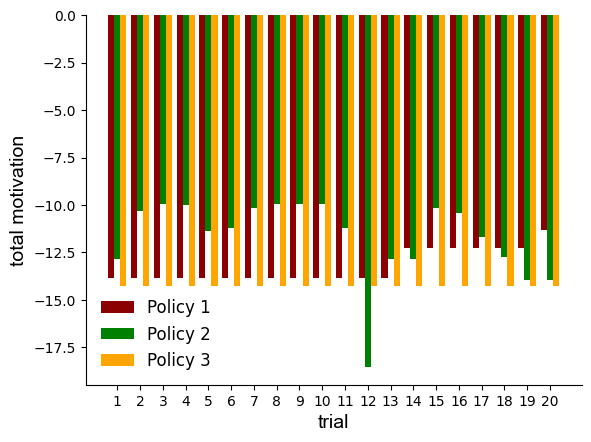

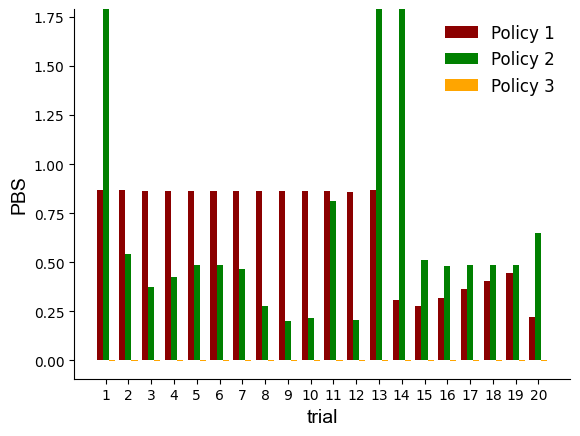

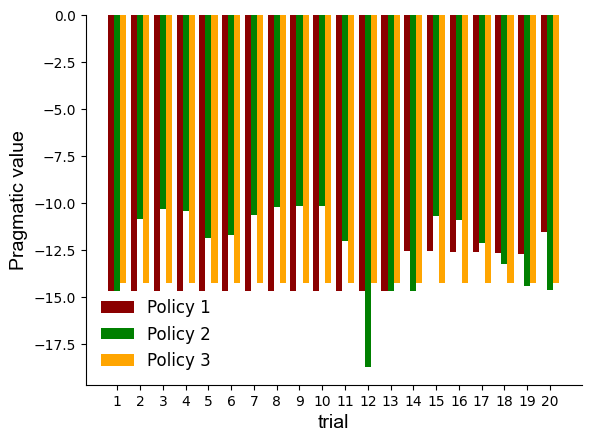

In [18]:
import matplotlib.pyplot as plt
import numpy as np

start=0#11
end=Timerange#22

if __name__ == "__main__": 
  #labels=['1','2','3','4','5','6','7','8','9','10']  # set the dates as labels
  #x0 = np.arange(len(labels))  # create an array of values for the ticks that can perform arithmetic with width (w)
  labels=[str(i) for i in range(start+1, end+1)]#T+1,11, 22
  print(labels)
  x0 = np.arange(end-start)#T

# create the data groups with a dict comprehension and groupby
  # マージンを設定
  margin = 0.2  #0 <margin< 1
  total_width = 1 - margin
  colors = ['darkred', 'green', 'orange', 'purple']
  #colors = ['darkred', 'green', 'orange']
#EFEの可視化
  fig, ax = plt.subplots()
  # 棒グラフをプロット
  """ for i, h in enumerate(EFE):
    pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
    plt.bar(pos, h, width = total_width/len(EFE)) """
  num_policies = num_slot+1
  #EFE_temp=-np.array(Pragmaticvalue)-np.array(PBS)-np.array(MI_model_o)*MI_mo_weight
  EFE_temp=np.array(PBS)+np.array(Pragmaticvalue)
  print(EFE_temp.shape)
  EFE_temp=EFE_temp[:,start:end] 
  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(EFE_temp) )/2
     ax.bar(pos, EFE_temp[i], color=colors[i],width=total_width/len(EFE_temp), label=f'Policy {i+1}')
  """ for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(pBS_pB) )/2
     ax.bar(pos, pBS_pB[i], color=colors[i],width=total_width/len(pBS_pB), label=f'Policy {i+1}') """
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel("total motivation", fontname="Arial", fontsize=14)
  #plt.ylabel("pBS_pB", fontname="Arial", fontsize=14)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  #plt.ylim(top=120) #17.5#30
  plt.show


  #EFEの可視化
  fig, ax = plt.subplots()
  data_list_tmp=np.array(PBS)[:,start:end] 
  # 棒グラフをプロット
  """ for i, h in enumerate(EFE):
    pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
    plt.bar(pos, h, width = total_width/len(EFE)) """
  num_policies = num_slot+1
  """ for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
     ax.bar(pos, EFE[i], width=total_width/len(EFE), label=f'Policy {i+1}') """
  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(data_list_tmp) )/2
     ax.bar(pos, data_list_tmp[i],color=colors[i], width=total_width/len(data_list_tmp), label=f'Policy {i+1}')
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel("PBS", fontname="Arial", fontsize=14)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  plt.ylim(top=1.79) #17.5#30
  plt.show
# build the plots
#subs = df.subsidiary.unique()
  stacks = num_slot  # how many stacks in each group for a tick location
# set the width
  w = 0.15

# #EFEの可視化
#   fig, ax = plt.subplots()
#   data_list_tmp=np.array(H_qo)[:,start:end] 
#   # 棒グラフをプロット
#   """ for i, h in enumerate(EFE):
#     pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
#     plt.bar(pos, h, width = total_width/len(EFE)) """
#   num_policies = num_slot
#   """ for i in range(num_policies):
#      pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
#      ax.bar(pos, EFE[i], width=total_width/len(EFE), label=f'Policy {i+1}') """
#   for i in range(num_policies):
#      pos = x0 - total_width *( 1- (2*i+1)/len(data_list_tmp) )/2
#      ax.bar(pos, data_list_tmp[i],color=colors[i], width=total_width/len(data_list_tmp), label=f'Policy {i+1}')
#   # ラベルの設定
#   plt.xticks(x0, labels)
#   plt.xlabel("trial", fontname="Arial", fontsize=14)
#   #plt.ylabel("EFE", fontname="Arial", fontsize=14)
#   plt.ylabel("Entropy", fontname="Arial", fontsize=14)
#   ax.spines['top'].set_visible(False)
#   ax.spines['right'].set_visible(False)
#   plt.legend(fontsize=12, frameon=False)
#   #plt.ylim(top=120) #17.5#30
#   plt.show


# build the plots


  #Pvの可視化
  fig, ax = plt.subplots()
  data_list_tmp=np.array(Pragmaticvalue)[:,start:end] 
 
  num_policies = num_slot+1

  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(data_list_tmp) )/2
     ax.bar(pos, data_list_tmp[i],color=colors[i], width=total_width/len(data_list_tmp), label=f'Policy {i+1}')
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel("Pragmatic value", fontname="Arial", fontsize=14)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  #plt.ylim(top=120) #17.5#30
  plt.show

In [19]:
Q_pi=np.array(Q_pi)
Q_pi=Q_pi[:,0,:]
Q_pi=Q_pi.T

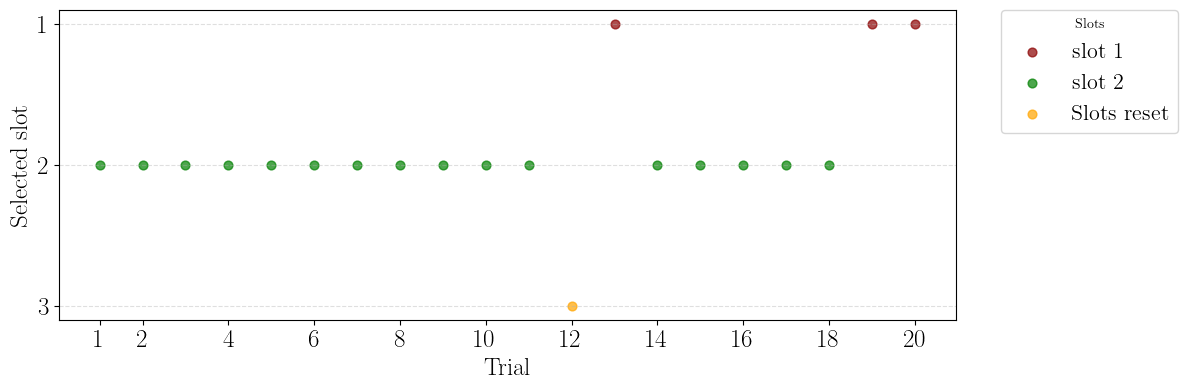

(np.float64(0.7894736842105263), np.int64(15))


In [20]:
##時系列で選択スロットを確認する

import matplotlib.pyplot as plt
import numpy as np

#selected_slot_array=
T2 = len(selected_slot_array)#[:-1]
x = np.arange(1, T2 + 1)
y = np.array(selected_slot_array)#[:-1]
#print(y)
font="Times new Roman"
# 色マップ定義（スロット番号 → 色）
colors = ['darkred', 'green', 'orange', 'purple']
slot_labels = [f"slot {i+1}" for i in range(num_slot)]+["Slots reset"]

plt.rcParams.update({
    "text.usetex": True,          # ←これが重要
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
})

plt.rcParams.update({
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
})

fig, ax = plt.subplots(figsize=(12, 4))



# スロットごとに分けてプロット
for slot in range(1,num_slot+2):
    slot_trials = x[y == slot]
    ax.scatter(slot_trials, [slot]*len(slot_trials), color=colors[slot-1], label=slot_labels[slot-1], s=40, alpha=0.7)

# 軸・表示設定
ax.set_xlabel("Trial", fontname=font, fontsize=18)
ax.set_ylabel("Selected slot", fontname=font, fontsize=18)
#ax.set_title("Slot selection over trials", fontname=font, fontsize=18)
#ax.set_yticks([i for i in range(num_slot)])#[1, 2, 3, 4]
ax.set_yticks([i for i in range(1, num_slot+2)])  # 1からnum_slotまでに変更
ax.set_xticks(np.linspace(1, T2, min(T2, 11), dtype=int))  
ax.legend(title="Slots", fontsize=18)
plt.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(title="Slots", fontsize=16, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax.invert_yaxis()  # y軸を反転
plt.tight_layout()



filename = f"Slot_slection_sa2{sa2}_sb{sb1}.tif"
plt.savefig(
    filename,
    format="tiff",
    dpi=600,                 # APA・多くのジャーナルで推奨
    bbox_inches="tight"
)

plt.show()

import numpy as np

def consecutive_ratio(selected_slot_array):
    # numpy配列に変換
    arr = np.array(selected_slot_array)
    
    # 隣同士を比較
    consecutive = arr[:-1] == arr[1:]
    
    # 一致している割合を計算
    ratio = consecutive.sum() / len(consecutive)
    return ratio,consecutive.sum()
print(consecutive_ratio(y)) 

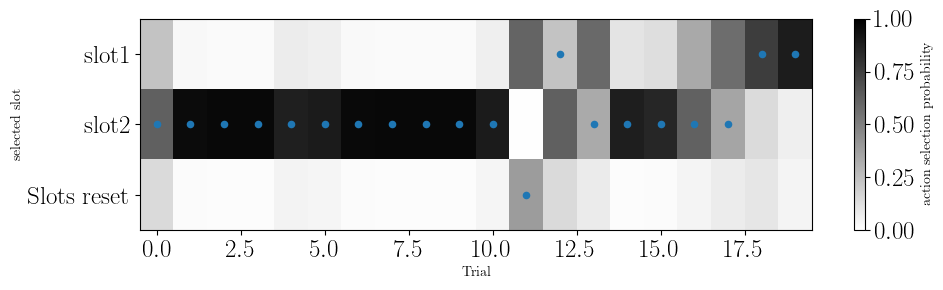

In [21]:
import numpy as np
import matplotlib.pyplot as plt


# ダミーデータ（実際はユーザーの Q_pi, y を使用）
# Q_pi = np.random.rand(2, 30)
# y = np.random.randint(0, 2, size=30)

y = np.array(selected_slot_array)
nT = Q_pi.shape[1]
#fig, ax = plt.subplots(figsize=(10, 3))

delta_y = -1#0.05  # 上寄りに見える分だけ下げる（必要に応じて -0.03 ～ -0.07 で微調整）

# im = ax.imshow(
#     Q_pi, cmap='gray_r', interpolation='nearest', aspect='auto',
#     extent=[-0.5, nT-0.5, -0.5, 1.5], origin='lower',
#     vmin=0.0, vmax=1.0
# )

# 1始まりなら 0始まりに補正
if y.min() >= 1 and y.max() <= num_slot+1:
    y = y - 1

fig, ax = plt.subplots(figsize=(10, max(3, 0.9 + 0.6*(num_slot+1))))

# 画像：x は -0.5..nT-0.5、y は -0.5..num_slots-0.5、上が slot1 になるように origin='upper'


im = ax.imshow(
    Q_pi, cmap='gray_r', interpolation='nearest', aspect='auto',
    extent=[-0.5, nT - 0.5, -0.5, num_slot+1 - 0.5],
    origin='lower', vmin=0.0, vmax=1.0
)

# 点（セル中心にそのまま打つ。オフセット不要）
x = np.arange(nT)
ax.scatter(x, y.astype(float), s=30, linewidths=0, zorder=3)

# 軸：y を反転して 0 を上（= slot1）にする
ax.set_xlim(-0.5, nT - 0.5)
ax.set_ylim(num_slot+1 - 0.5, -0.5)       # ← ここで上下反転（invert_yaxis()でも可）

ax.set_xlabel("Trial")
ax.set_ylabel("selected slot")
ax.set_yticks(range(num_slot+1))
ax.set_yticklabels([f"slot{i+1}" for i in range(num_slot)]+["Slots reset"])

fig.colorbar(im, ax=ax, label="action selection probability")
plt.tight_layout()
plt.show()


# x = np.arange(nT)
# ax.scatter(x, y.astype(float) + delta_y, color='blue', s=30, linewidths=0, zorder=3)

# ax.set_xlim(-0.5, nT-0.5)
# ax.set_ylim(-0.5, 1.5)
# ax.set_xlabel("Trial")
# ax.set_ylabel("selected slot")
# ax.set_yticks([0, 1])
# ax.set_yticklabels(["slot1", "slot2"])  # ここでラベルを変更
# ax.invert_yaxis()  # ★これで上下逆転

# fig.colorbar(im, ax=ax, label="action selection probability")
# plt.tight_layout()
# plt.show()


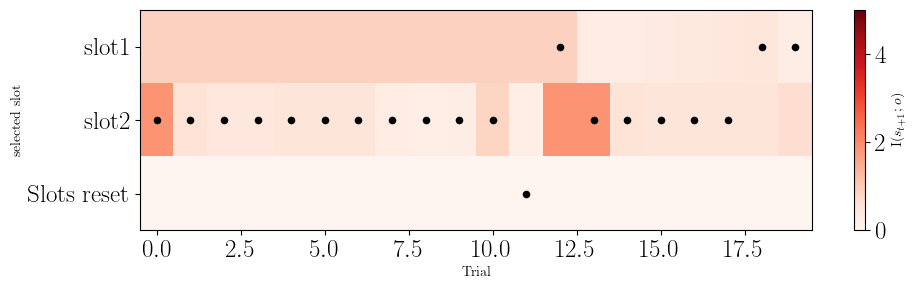

In [22]:
import numpy as np
import matplotlib.pyplot as plt

PBS=np.array(PBS)
# ダミーデータ（実際はユーザーの Q_pi, y を使用）
# Q_pi = np.random.rand(2, 30)
# y = np.random.randint(0, 2, size=30)

y = np.array(selected_slot_array)
nT = PBS.shape[1]
fig, ax = plt.subplots(figsize=(10, 3))

delta_y = -1#0.05  # 上寄りに見える分だけ下げる（必要に応じて -0.03 ～ -0.07 で微調整）
# 1始まりなら 0始まりに補正
if y.min() >= 1 and y.max() <= num_slot+1:
    y = y - 1

im = ax.imshow(
    PBS, cmap='Reds', interpolation='nearest', aspect='auto',
    extent=[-0.5, nT - 0.5, -0.5, num_slot+1 - 0.5],
    origin='lower', vmin=0.0, vmax=5
)

# 点（セル中心にそのまま打つ。オフセット不要）
x = np.arange(nT)
ax.scatter(x, y.astype(float),color='black', s=30, linewidths=0, zorder=3)

# 軸：y を反転して 0 を上（= slot1）にする
ax.set_xlim(-0.5, nT - 0.5)
ax.set_ylim(num_slot+1 - 0.5, -0.5)       

ax.set_xlabel("Trial")
ax.set_ylabel("selected slot")
ax.set_yticks(range(num_slot+1))
ax.set_yticklabels([f"slot{i+1}" for i in range(num_slot)]+["Slots reset"])

fig.colorbar(im, ax=ax, label=r'I($s_{t+1};o$)')
plt.tight_layout()
plt.show()

# im = ax.imshow(
#     PBS, cmap='Reds', interpolation='nearest', aspect='auto',
#     extent=[-0.5, nT-0.5, -0.5, 1.5], origin='lower',
#     vmin=0.0, vmax=5
# )

# x = np.arange(nT)
# ax.scatter(x, y.astype(float) + delta_y, color='black', s=30, linewidths=0, zorder=3)

# ax.set_xlim(-0.5, nT-0.5)
# ax.set_ylim(-0.5, 1.5)
# ax.set_xlabel("Trial")
# ax.set_ylabel("selected slot")
# ax.set_yticks([0, 1])
# ax.set_yticklabels(["slot1", "slot2"])  # ここでラベルを変更
# ax.invert_yaxis()  # ★これで上下逆転
# #ax.set_title("Q_pi visualization with y overlay")
# #ax.legend(loc="upper right")

# fig.colorbar(im, ax=ax, label="I(s;o)")
# plt.tight_layout()
# plt.show()

 slot_counts is [3, 16, 1]


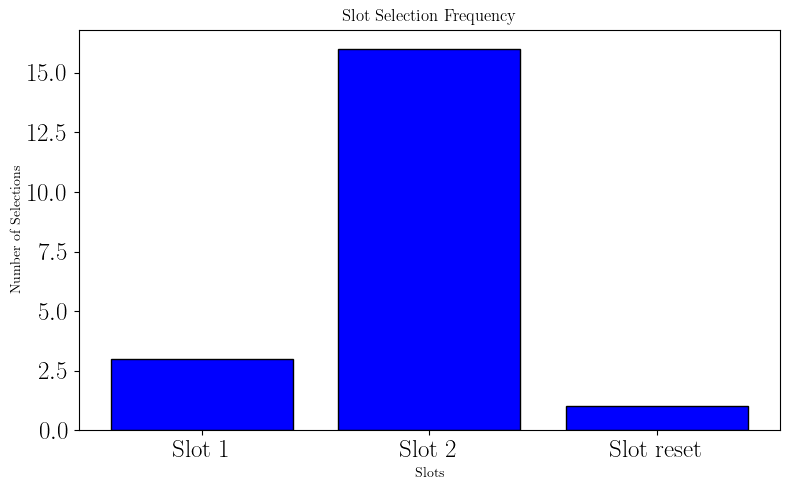

In [23]:
#選択されたスロットを集計
print(f' slot_counts is {slot_counts}')

%matplotlib inline

#棒グラフ化
import matplotlib.pyplot as plt
# スロット番号（1〜4）をラベルとして使用
slot_labels = [f'Slot {i+1}' for i in range(num_slot)]+['Slot reset']
#slot_labels = ['Slot 1', 'Slot 2', 'Slot 3', 'Slot 4']
# グラフを描画
plt.figure(figsize=(8, 5))
plt.bar(slot_labels, slot_counts, color='blue', edgecolor='black')
# タイトルとラベルの設定
plt.title('Slot Selection Frequency')
plt.xlabel('Slots')
plt.ylabel('Number of Selections')
# グリッド線と表示
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()
plt.show()


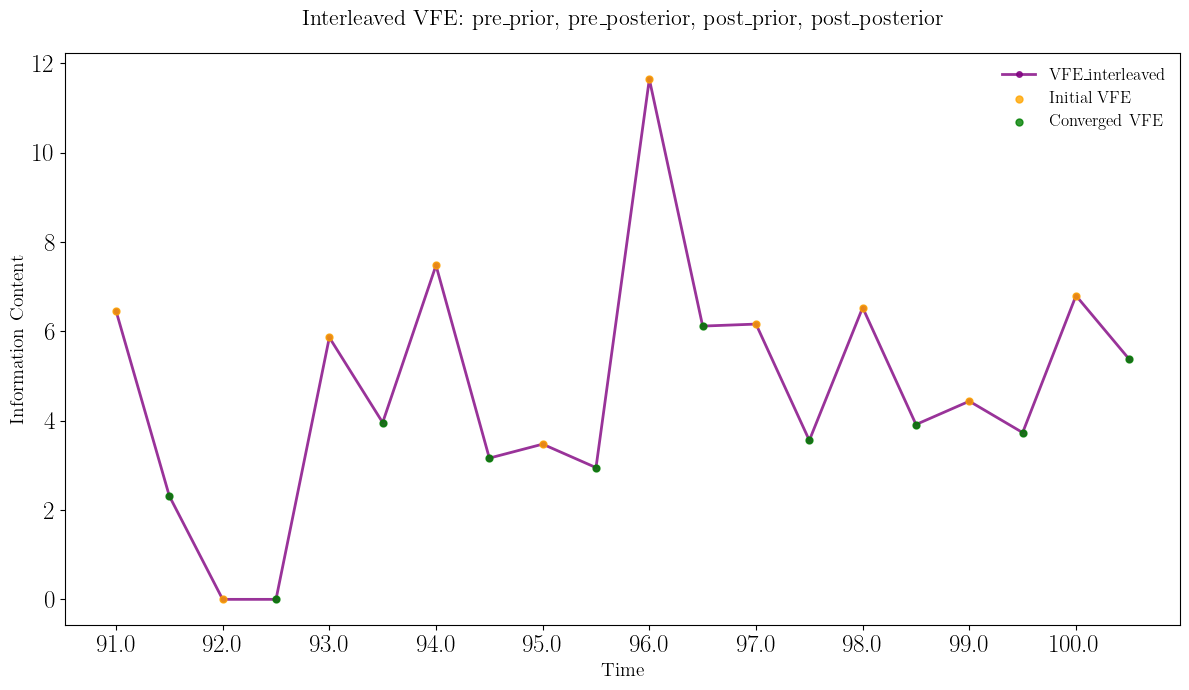

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# 2つのリストを順番に交互に結合する関数
def interleave_4lists(l1, l2):
    result = []
    max_len = max(len(l1), len(l2))
    for i in range(max_len):
        if i < len(l1):
            result.append(l1[i])
        if i < len(l2):
            result.append(l2[i])
        
    return result

# データをスカラー値に変換する関数（既存のものを流用）
def convert_to_scalars(data):
    scalars = []
    data_array = np.array(data)
    for i in range(len(data_array)):
        item = data_array[i]
        if hasattr(item, '__array__'):
            if item.ndim == 0:
                scalars.append(float(item))
            else:
                scalars.append(float(item[0]))
        else:
            scalars.append(float(item))
    return scalars

# 4つのVFEデータをスカラー値リストに変換
prior_scalars = convert_to_scalars(prior_VFE)
posterior_scalars = convert_to_scalars(posterior_VFE)


# 4つのリストを交互に結合
VFE_interleaved = interleave_4lists(prior_scalars, posterior_scalars)
VFE_interleaved=np.array(VFE_interleaved)[-20:]
VFE_interleaved=list(VFE_interleaved)

# 時間軸
time_points_interleaved = range(1, len(VFE_interleaved) + 1)

# プロット
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(time_points_interleaved, VFE_interleaved, color='purple', marker='o', markersize=4, label='VFE_interleaved', linewidth=2, alpha=0.8)

# それぞれの系列ごとに色分けしてプロット
indices = [list(range(i, len(VFE_interleaved), 2)) for i in range(2)]
colors = [ 'orange', 'green']
labels = ['Initial VFE', 'Converged VFE']

for idx, color, label in zip(indices, colors, labels):
    values = [VFE_interleaved[i] for i in idx]
    time_points = [i+1 for i in idx]
    ax.scatter(time_points, values, color=color, marker='o', s=25, label=label, alpha=0.8, zorder=5)

ax.set_xticks(np.linspace(1, len(VFE_interleaved), min(len(VFE_interleaved), 11), dtype=int))
ax.set_xlabel('Time', fontsize=14, fontweight='bold')
ax.set_ylabel('Information Content', fontsize=14, fontweight='bold')
ax.set_title('Interleaved VFE: pre_prior, pre_posterior, post_prior, post_posterior', fontsize=16, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=12, loc='upper right')
ax.autoscale_view()
# 4つおきのx軸目盛りの位置
xticks = list(range(0, len(VFE_interleaved), 2))
ax.set_xticks([i+1 for i in xticks])  # 1始まりに調整
# ラベルは1, 2, 3...と表示
ax.set_xticklabels([str(i*0.5+91) for i in xticks])
plt.tight_layout()
plt.show()

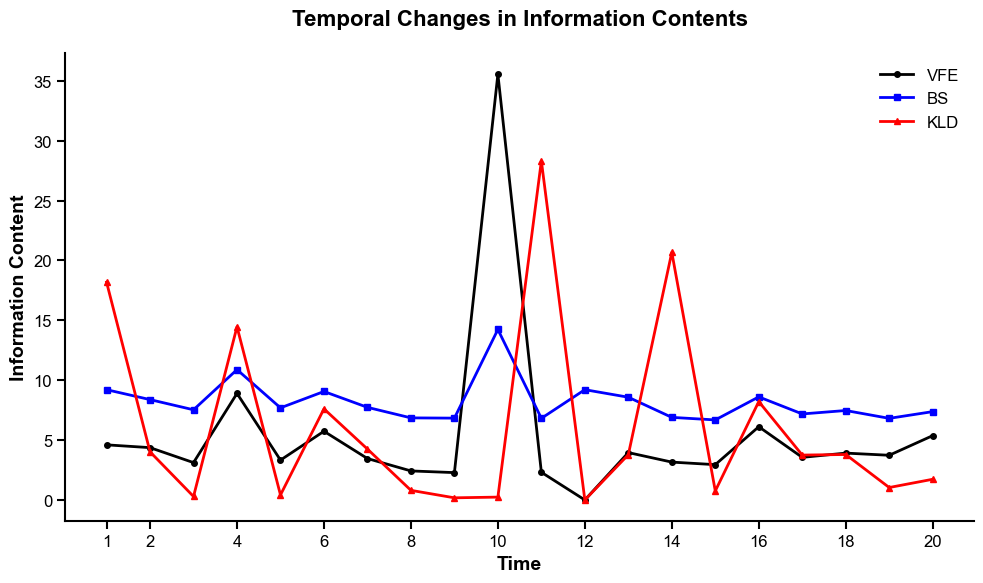

In [25]:
import matplotlib.pyplot as plt
import numpy as np

KLD_temp =list(map(lambda x: x , KLD)) #list(map(lambda x: x / 10, KLD))
#print(divided_list)  # [1.0, 2.0, 3.0, 4.0, 5.0]
# APAスタイルの設定
plt.style.use('default')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['lines.linewidth'] = 2


# データの準備（例として、VFE、BS、KLDのリストが既に存在することを前提）
# 実際のデータに合わせて調整してください
#time_points = range(len(VFE))  # 時間軸
time_points = range(1, len(posterior_VFE) + 1)
# 図の作成
fig, ax = plt.subplots(figsize=(10, 6))
# 三つの折れ線グラフを描画
ax.plot(time_points, posterior_VFE, color='black', marker='o', markersize=4, label='VFE', linewidth=2)
ax.plot(time_points, BS, color='blue', marker='s', markersize=4, label='BS', linewidth=2)
ax.plot(time_points, KLD_temp, color='red', marker='^', markersize=4, label='KLD', linewidth=2)



# 軸の設定
ax.set_xticks(np.linspace(1, len(posterior_VFE), min(len(posterior_VFE), 11), dtype=int))
ax.set_xlabel('Time', fontsize=14, fontweight='bold')
ax.set_ylabel('Information Content', fontsize=14, fontweight='bold')
ax.set_title('Temporal Changes in Information Contents', fontsize=16, fontweight='bold', pad=20)
# グリッドの設定
#ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
# 凡例の設定
ax.legend(frameon=False, fontsize=12, loc='upper right')
# 軸の範囲を自動調整
ax.autoscale_view()
# レイアウトの調整
plt.tight_layout()
# グラフの表示
plt.show()

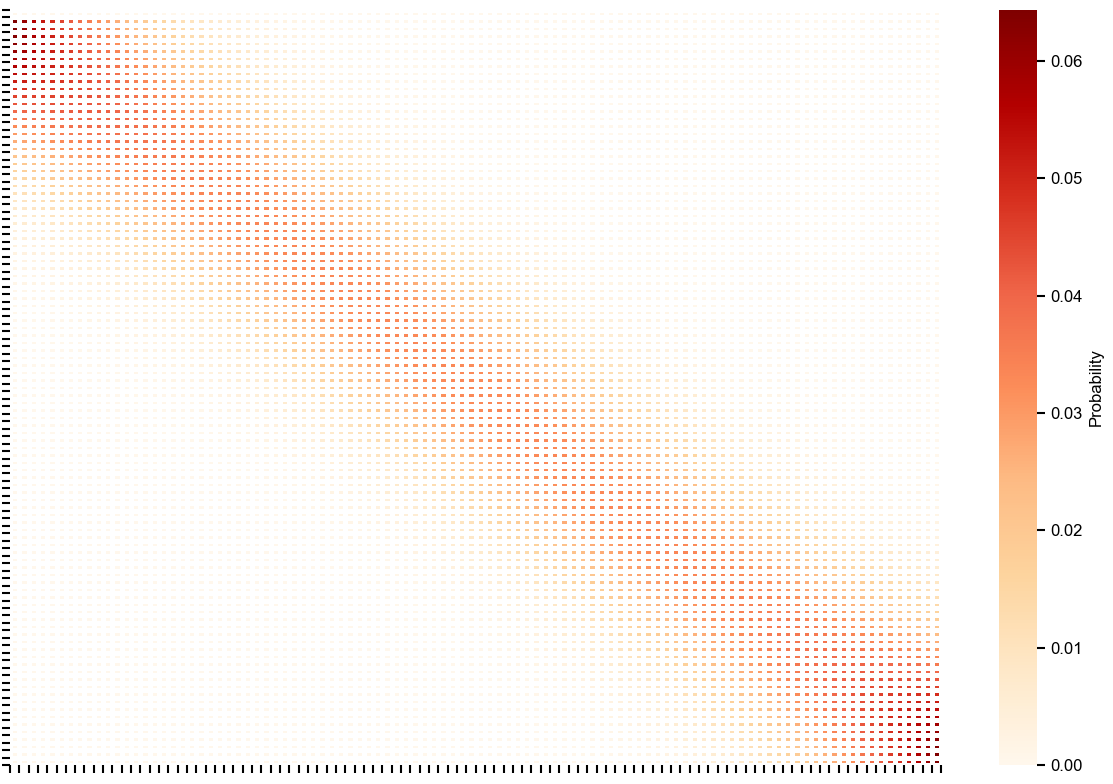

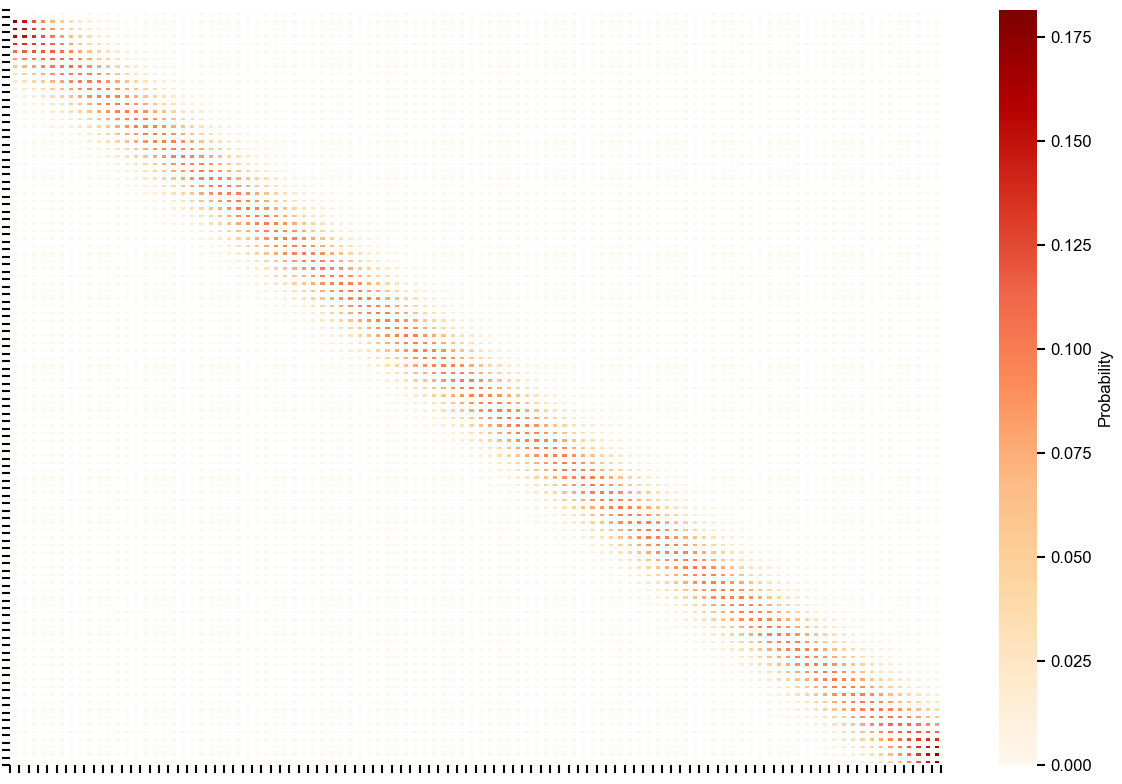

' plot_likelihood_figsize(agents.A[1][0][:,:,1] )\nplot_likelihood_figsize(agents.A[2][0][:,:,2] )\nplot_likelihood_figsize(agents.A[3][0][:,:,3] ) '

In [26]:
for i in range (num_slot):
    plot_likelihood_figsize(agents.A[i][0][:,:,i] )

""" plot_likelihood_figsize(agents.A[1][0][:,:,1] )
plot_likelihood_figsize(agents.A[2][0][:,:,2] )
plot_likelihood_figsize(agents.A[3][0][:,:,3] ) """

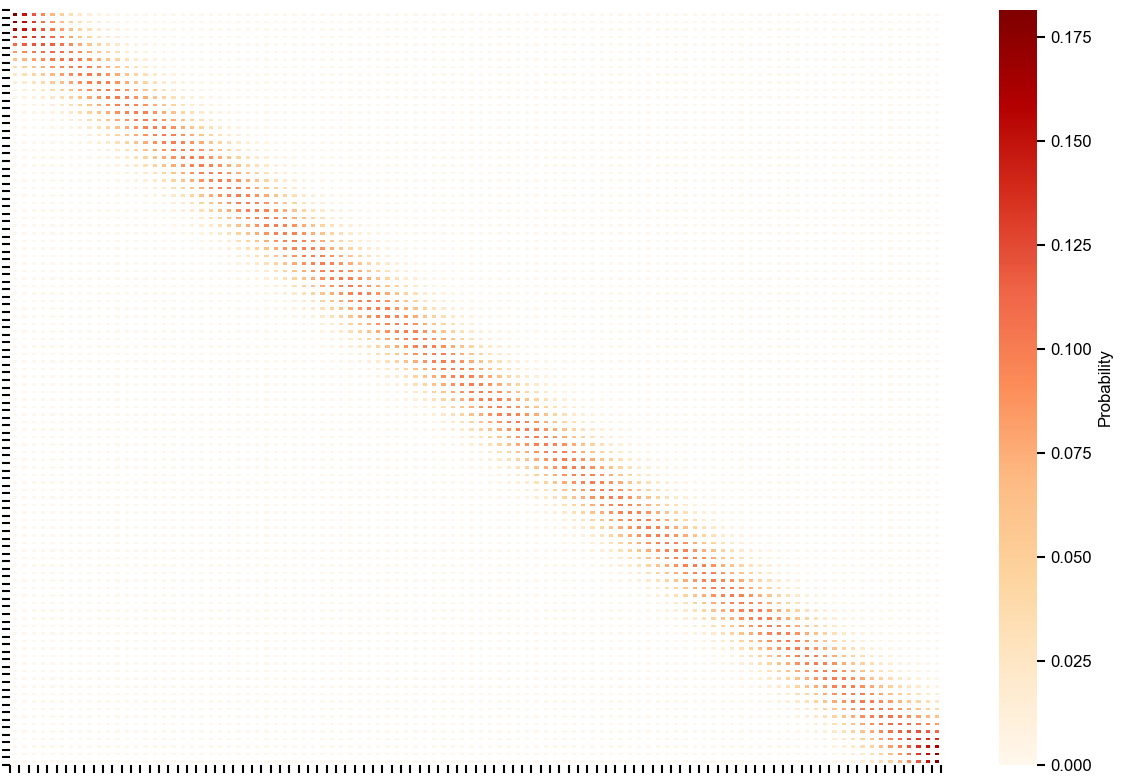

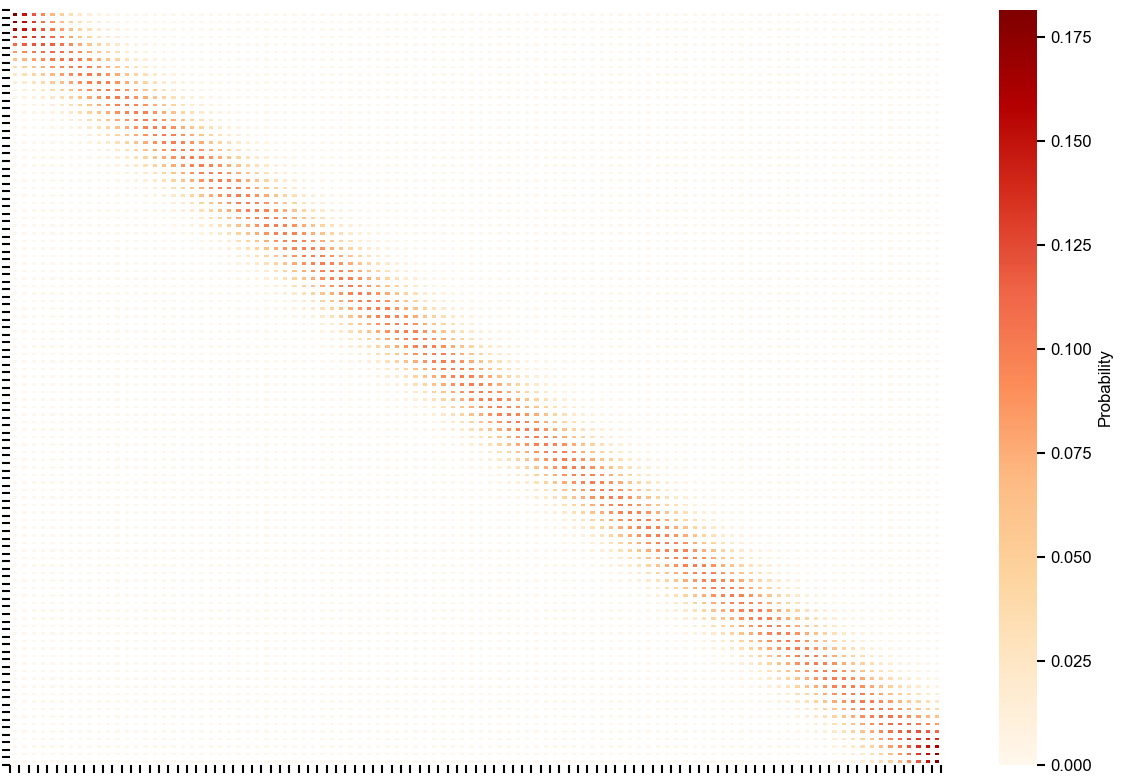

In [27]:
for i in range (num_slot):
    plot_likelihood_figsize(agents.B[i][0][:,:,i] )
# plot_likelihood_figsize(agents.B[0][0][:,:,0] )
# plot_likelihood_figsize(agents.B[1][0][:,:,1] )
# plot_likelihood_figsize(agents.B[2][0][:,:,2] )
# plot_likelihood_figsize(agents.B[3][0][:,:,3] )